In [1]:
from owlready2 import *
import configparser
import multiprocessing
import os
import random
import sys
import time
import click
import logging
import networkx as nx
import matplotlib.pyplot as plt
import gensim
from nxontology.imports import from_file
from owl2vec_star.lib.RDF2Vec_Embed import get_rdf2vec_walks
from owl2vec_star.lib.Label import pre_process_words, URI_parse
from owl2vec_star.lib.Onto_Projection import Reasoner, OntologyProjection

import nltk

ModuleNotFoundError: No module named 'owl2vec_star'

In [2]:
onto = get_ontology(r"G:\Research\Github\KANO\KGembedding\elementkg.owl")
onto.load()

* Owlready2 * WARNING: ObjectProperty http://www.semanticweb.org/ElementKG#hasStateSolid belongs to more than one entity types: [owl.SymmetricProperty, owl.ObjectProperty, owl.AnnotationProperty, owl.TransitiveProperty, owl.topObjectProperty]; I'm trying to fix it...
* Owlready2 * WARNING: ObjectProperty http://www.semanticweb.org/ElementKG#hasStateLiquid belongs to more than one entity types: [owl.AnnotationProperty, owl.TransitiveProperty, owl.SymmetricProperty, owl.ObjectProperty, owl.topObjectProperty]; I'm trying to fix it...


get_ontology("http://www.semanticweb.org/ElementKG#")

In [3]:
print(onto.base_iri)
print(onto.classes())
print(onto.individuals())
print(onto.object_properties())  # object properties
print(onto.data_properties())

http://www.semanticweb.org/ElementKG#
<generator object _GraphManager.classes at 0x0000021652466730>
<generator object _GraphManager.individuals at 0x0000021652466730>
<generator object _GraphManager.object_properties at 0x0000021652466730>
<generator object _GraphManager.data_properties at 0x0000021652466730>


In [4]:
for i in onto.individuals():
    #print(i)
    # 在i中删除'G:\Research\Github\KANO\KGembedding\elementkg.'
    print(i.name)

Sc
Li
Dy
Ho
Sn
Yb
Pu
Zn
Ag
Ta
Bk
Pm
Sb
Ti
Tb
Ir
Fm
Y
Te
Na
Am
Cs
Br
Nd
I
Pa
La
No
Co
Ge
As
Al
Cu
Cr
Mn
Si
Ra
Pt
Ca
Se
Pb
Ac
Bi
Sr
Lu
Hg
Np
Rb
Kr
Pd
U
Ce
Ru
Sm
Cl
Eu
Tc
Er
S
Cd
Ga
Hf
Gd
Fe
Zr
Mg
Ni
Pr
Rf
O
Tm
Nb
B
Md
K
P
Es
Th
Xe
F
He
Lr
Cf
Ba
Ne
In
V
H
Mo
Po
C
Rh
Tl
W
Re
Be
Cm
At
Os
N
Ar
Au
Rn
Ts
Rg
Og
Fr
Ds
Mt
Fl
Lv
Sg
Bh
Cn
Nh
Mc
Db
Hs
Boronate
Borino
Borinate
Borono
halo
iodo
Carbodithio
Sulfinyl
CarbothioicSAcid
Sulfonyl
CarbothioicOAcid
CarbodithioicAcid
Sulfino
Sulfonate
Sulfhydryl
Thiolester
Sulfo
Isothiocyanate
Thionoester
Pyridyl
Nitro
Nitrosooxy
SecondaryAmine
SecondaryAldimine
Carboxamide
4ammoniumIon
PrimaryAldimine
SecondaryKetimine
Nitroso
TertiaryAmine
PrimaryAmine
Cyanate
Azo
PrimaryKetimine
Carbamate
Isonitrile
Isocyanate
fluoro
chloro
Phosphono
Hydroxyl
Alkenyl
Alkynyl
Alkyl
Phenyl
Hydroperoxy
Carboxyl
Methylenedioxy
Peroxy
Carbonyl
CarbonateEster
CarboxylicAnhydride
Carboalkoxy
Haloformyl
bromo
Phosphino
Sulfoate


* Owlready2 * Warning: ignoring cyclic type of, involving storid 506

* Owlready2 * Warning: ignoring cyclic type of, involving storid 510

* Owlready2 * Warning: ignoring cyclic type of, involving storid 514

* Owlready2 * Warning: ignoring cyclic type of, involving storid 515

* Owlready2 * Warning: ignoring cyclic type of, involving storid 516

* Owlready2 * Warning: ignoring cyclic type of, involving storid 518

* Owlready2 * Warning: ignoring cyclic type of, involving storid 521

* Owlready2 * Warning: ignoring cyclic type of, involving storid 526

* Owlready2 * Warning: ignoring cyclic type of, involving storid 543

* Owlready2 * Warning: ignoring cyclic type of, involving storid 545

* Owlready2 * Warning: ignoring cyclic type of, involving storid 549

* Owlready2 * Warning: ignoring cyclic type of, involving storid 550

* Owlready2 * Warning: ignoring cyclic type of, involving storid 552

* Owlready2 * Warning: ignoring cyclic type of, involving storid 556

* Owlready2 * Warnin

In [2]:
config = configparser.ConfigParser()
config_path = r"G:\Research\Github\KANO\KGembedding\default.cfg"
owl_path = r"G:\Research\Github\KANO\KGembedding\elementkg.owl"

In [7]:
config.read(click.format_filename(config_path))
config['DOCUMENT']['URI_Doc'] = 'yes'
config['DOCUMENT']['Lit_Doc'] = 'yes'
config['DOCUMENT']['Mix_Doc'] = 'yes'
if not os.path.exists(config['DOCUMENT']['cache_dir']):
    os.mkdir(config['DOCUMENT']['cache_dir'])

In [4]:
logging.basicConfig(format='%(levelname)s: %(message)s', level=logging.INFO)
if ('ontology_projection' in config['DOCUMENT'] and config['DOCUMENT']['ontology_projection'] == 'yes') or \
    'pre_entity_file' not in config['DOCUMENT'] or 'pre_axiom_file' not in config['DOCUMENT'] or \
    'pre_annotation_file' not in config['DOCUMENT']:
    logging.info('Access the ontology ...')

    tax_only = (config['DOCUMENT']['projection_only_taxonomy'] == "yes")
    
    projection = OntologyProjection(config['BASIC']['ontology_file'], reasoner=Reasoner.STRUCTURAL,
                                    only_taxonomy=tax_only,
                                    bidirectional_taxonomy=True, include_literals=True, avoid_properties=set(),
                                    additional_preferred_labels_annotations=set(),
                                    additional_synonyms_annotations=set(),
                                    memory_reasoner='13351')
else:
    projection = None

INFO: Access the ontology ...
* Owlready2 * WARNING: ObjectProperty http://www.semanticweb.org/ElementKG#hasStateSolid belongs to more than one entity types: [owl.SymmetricProperty, owl.ObjectProperty, owl.AnnotationProperty, owl.TransitiveProperty, owl.topObjectProperty]; I'm trying to fix it...
* Owlready2 * WARNING: ObjectProperty http://www.semanticweb.org/ElementKG#hasStateLiquid belongs to more than one entity types: [owl.AnnotationProperty, owl.TransitiveProperty, owl.SymmetricProperty, owl.ObjectProperty, owl.topObjectProperty]; I'm trying to fix it...
INFO: There are 52414 triples in the ontology


In [8]:
projection

In [22]:
# Ontology projection
if 'ontology_projection' in config['DOCUMENT'] and config['DOCUMENT']['ontology_projection'] == 'yes':
    logging.info('Calculate the ontology projection ...')
    projection.extractProjection()
    onto_projection_file = os.path.join(config['DOCUMENT']['cache_dir'], 'projection.ttl')
    projection.saveProjectionGraph(onto_projection_file)
    ontology_file = onto_projection_file
else:
    ontology_file = config['BASIC']['ontology_file']

INFO: Calculate the ontology projection ...
INFO: Creating ontology graph projection...
INFO: 	Extracting subsumption triples
INFO: 		Time extracting subsumption: 0.06562590599060059 seconds 
INFO: 	Extracting equivalence triples
INFO: 		Time extracting equivalences: 0.013016700744628906 seconds 
INFO: 	Extracting class membership triples.
INFO: 		Time extracting class membership: 0.35167837142944336 seconds 
INFO: 	Extracting sameAs triples
INFO: 		Time extracting sameAs: 0.007514476776123047 seconds 
INFO: 	Extracting triples associated to hasRadius3
INFO: 		Time extracting triples for property: 0.3297901153564453 seconds 
INFO: 	Extracting triples associated to hasBoilingPoint7
INFO: 		Time extracting triples for property: 0.34235525131225586 seconds 
INFO: 	Extracting triples associated to hasHardness3
INFO: 		Time extracting triples for property: 0.37757325172424316 seconds 
INFO: 	Extracting triples associated to hasElectronAffinity2
INFO: 		Time extracting triples for property: 

In [27]:
# Extract and save seed entities (classes and individuals)
# Or read entities specified by the user
if 'pre_entity_file' in config['DOCUMENT']:
    entities = [line.strip() for line in open(config['DOCUMENT']['pre_entity_file']).readlines()]
else:
    logging.info('Extract classes and individuals ...')
    projection.extractEntityURIs()
    classes = projection.getClassURIs()   # 蓝色的类别
    individuals = projection.getIndividualURIs() # 红色的实体
    entities = classes.union(individuals) # 上面两个拼在一起了
    with open(os.path.join(config['DOCUMENT']['cache_dir'], 'entities.txt'), 'w') as f:
        for e in entities:
            f.write('%s\n' % e)

INFO: Extract classes and individuals ...


In [39]:
# If pre_annotation_file is set, directly read annotations
# else, read annotations including rdfs:label and other literals from the ontology
#   Extract annotations: 1) English label of each entity, by rdfs:label or skos:preferredLabel
#                        2) None label annotations as sentences of the literal document
uri_label, uri_to_labels, annotations = dict(), dict(), list()

if 'pre_annotation_file' in config['DOCUMENT']:
    with open(config['DOCUMENT']['pre_annotation_file']) as f:
        for line in f.readlines():
            tmp = line.strip().split()
            if tmp[1] == 'http://www.w3.org/2000/01/rdf-schema#label':
                uri_label[tmp[0]] = pre_process_words(tmp[2:])
            else:
                annotations.append([tmp[0]] + tmp[2:])

else:
    logging.info('Extract annotations ...')
    projection.indexAnnotations()
    for e in entities:
        if e in projection.entityToPreferredLabels and len(projection.entityToPreferredLabels[e]) > 0:
            label = list(projection.entityToPreferredLabels[e])[0]
            #Keeps only one
            uri_label[e] = pre_process_words(words=label.split())



            ##Populates dictionary with all labels per entity
            for label in projection.getPreferredLabelsForEntity(e):
                #print("Preferred: " + label)
                if e not in uri_to_labels:
                    uri_to_labels[e]=set()
                #We add a list of words in the set
                #print(pre_process_words(words=label.split()))
                #print(uri_to_labels[e])
                uri_to_labels[e].add(tuple(pre_process_words(words=label.split())))
    
            if e in projection.entityToSynonyms and len(projection.entityToSynonyms[e]) > 0:
                for label in projection.getSynonymLabelsForEntity(e):
                    #print("Syn: " + label)
                    if e not in uri_to_labels:
                        uri_to_labels[e]=set()
                    #We add a list of words in the set
                    uri_to_labels[e].add(tuple(pre_process_words(words=label.split())))
                
    for e in entities:
        if e in projection.entityToAllLexicalLabels:
            for v in projection.entityToAllLexicalLabels[e]:
                if (v is not None) and \
                    (not (e in projection.entityToPreferredLabels and v in projection.entityToPreferredLabels[e])):
                    annotation = [e] + v.split()
                    annotations.append(annotation)

    with open(os.path.join(config['DOCUMENT']['cache_dir'], 'annotations.txt'), 'w') as f:
        for e in projection.entityToPreferredLabels:
            for v in projection.entityToPreferredLabels[e]:
                f.write('%s preferred_label %s\n' % (e, v))
        for a in annotations:
            f.write('%s\n' % ' '.join(a))

INFO: Extract annotations ...


In [44]:
# read URI document
# two parts: walks, axioms (if the axiom file exists)
walk_sentences, axiom_sentences, URI_Doc = list(), list(), list()
if 'URI_Doc' in config['DOCUMENT'] and config['DOCUMENT']['URI_Doc'] == 'yes':
    logging.info('Generate URI document ...')
    walks_ = get_rdf2vec_walks(onto_file=ontology_file, walker_type=config['DOCUMENT']['walker'],
                                walk_depth=int(config['DOCUMENT']['walk_depth']), classes=entities)
    logging.info('Extracted %d walks for %d seed entities' % (len(walks_), len(entities)))
    walk_sentences += [list(map(str, x)) for x in walks_]

    axiom_file = os.path.join(config['DOCUMENT']['cache_dir'], 'axioms.txt')
    if os.path.exists(axiom_file):
        for line in open(axiom_file).readlines():
            axiom_sentence = [item for item in line.strip().split()]
            axiom_sentences.append(axiom_sentence)
    logging.info('Extracted %d axiom sentences' % len(axiom_sentences))
    URI_Doc = walk_sentences + axiom_sentences

INFO: Generate URI document ...
INFO: Extracted 1548405 walks for 282 seed entities
INFO: Extracted 0 axiom sentences


In [49]:
# Some entities have English labels
# Keep the name of built-in properties (those starting with http://www.w3.org)
# Some entities have no labels, then use the words in their URI name
def label_item(item):
    if item in uri_label:
        return uri_label[item]
    elif item.startswith('http://www.w3.org'):
        return [item.split('#')[1].lower()]
    elif item.startswith('http://'):
        return URI_parse(uri=item)
    else:
        return [item.lower()]
    
    #New algorithm for multiple labels
def getExtendedSentences(sentence, syn_dict, max_labels=5):
    sentences = list()
    tmp_sentences = list()

    for i, entity in enumerate(sentence):
        #print(i)
        if entity in syn_dict:
            for j, l in enumerate(syn_dict[entity]):
                if j > max_labels:
                    break
                # Initialization
                if (i == 0):
                    sentences = sentences + [l]  # "l" already as a list
                else:
                    for s in sentences:
                        s = s + l  # already as a list of words
                        tmp_sentences = tmp_sentences + [s]
                        # print(s)
        else:
            #For cases not in dictionary like OWL constructs
            for s in sentences:
                s = s + tuple(label_item(entity))  # already as a list of words
                tmp_sentences = tmp_sentences + [s]
                # print(s)

        if (i > 0):
            sentences.clear()
            sentences = [s for s in tmp_sentences]
            tmp_sentences.clear()


    return sentences

In [54]:
# read literal document
# two parts: literals in the annotations (subject's label + literal words)
#            replacing walk/axiom sentences by words in their labels
Lit_Doc = list()
if 'Lit_Doc' in config['DOCUMENT'] and config['DOCUMENT']['Lit_Doc'] == 'yes':
    logging.info('Generate literal document ...')
    for annotation in annotations:
        processed_words = pre_process_words(annotation[1:])
        if len(processed_words) > 0:
            Lit_Doc.append(label_item(item=annotation[0]) + processed_words)
    logging.info('Extracted %d annotation sentences' % len(Lit_Doc))


    #Only applied to the walks?
    if 'multiple_labels' in config['DOCUMENT'] and config['DOCUMENT']['multiple_labels'] == "yes":
        for sentence in walk_sentences:
            for lit_sentence in getExtendedSentences(sentence, uri_to_labels, 5):
                Lit_Doc.append(lit_sentence)


    else: #Single label
        for sentence in walk_sentences:
            lit_sentence = list()
            for item in sentence:
                lit_sentence += label_item(item=item)
            Lit_Doc.append(lit_sentence)




    for sentence in axiom_sentences:
        lit_sentence = list()
        for item in sentence:
            lit_sentence += label_item(item=item)
        Lit_Doc.append(lit_sentence)

INFO: Generate literal document ...
INFO: Extracted 0 annotation sentences


In [56]:
# read mixture document
# for each axiom/walk sentence
#   -    all): for each entity, keep its entity URI, replace the others by label words
#   - random): randomly select one entity, keep its entity URI, replace the others by label words
Mix_Doc = list()
if 'Mix_Doc' in config['DOCUMENT'] and config['DOCUMENT']['Mix_Doc'] == 'yes':
    logging.info('Generate mixture document ...')
    for sentence in walk_sentences + axiom_sentences:
        if config['DOCUMENT']['Mix_Type'] == 'all':
            for index in range(len(sentence)):
                mix_sentence = list()
                for i, item in enumerate(sentence):
                    mix_sentence += [item] if i == index else label_item(item=item)
                Mix_Doc.append(mix_sentence)
        elif config['DOCUMENT']['Mix_Type'] == 'random':
            random_index = random.randint(0, len(sentence) - 1)
            mix_sentence = list()
            for i, item in enumerate(sentence):
                mix_sentence += [item] if i == random_index else label_item(item=item)
            Mix_Doc.append(mix_sentence)

INFO: Generate mixture document ...


In [58]:
len(Mix_Doc)

1548405

In [59]:
logging.info('URI_Doc: %d, Lit_Doc: %d, Mix_Doc: %d' % (len(URI_Doc), len(Lit_Doc), len(Mix_Doc)))
all_doc = URI_Doc + Lit_Doc + Mix_Doc

#logging.info('Time for document construction: %s seconds' % (time.time() - start_time))
random.shuffle(all_doc)


#Save all_doc (optional): default: no
if config['DOCUMENT']['save_document'] == 'yes':
    with open(os.path.join(config['DOCUMENT']['cache_dir'], 'document_sentences.txt'), 'w') as f:
        for sentence in all_doc:
            for w in sentence:
                f.write('%s ' % w)
            f.write('\n')
        f.close()

INFO: URI_Doc: 1548405, Lit_Doc: 0, Mix_Doc: 1548405


In [62]:
len(URI_Doc)

1548405

In [ ]:
# 这3个文档，可能是文中提到的3个文档

加载owl文件为rdfls文件

In [4]:
import rdflib
import os

In [5]:
g = rdflib.Graph()

In [6]:
g.parse(owl_path)

<Graph identifier=N217b2534856745caa265b2392be0eca8 (<class 'rdflib.graph.Graph'>)>

In [7]:
print(len(g))

52413


In [8]:
# 三元组的关系
entities, relations, triples = set(), set(), list()
i = 0 
for (s,p,o) in g:
    if i > 999999:
        break
    s, p, o = str(s), str(p), str(o)
    s = s.strip().replace('\t', ' ').replace('\n', '')
    p = p.strip().replace('\t', ' ').replace('\n', '')
    o = o.strip().replace('\t', ' ').replace('\n', '')
    # 在spo中删除http://www.semanticweb.org/ElementKG
    s = s.replace('http://www.semanticweb.org/ElementKG', '')
    p = p.replace('http://www.semanticweb.org/ElementKG', '')
    o = o.replace('http://www.semanticweb.org/ElementKG', '')
    
    if s == '' or p == '' or o == '':
        continue
    print(s,p,o)
    triples.append([s, p, o])
    entities.add(s)  # s是实体
    entities.add(o)  # o也是实体
    relations.add(p) # p是关系
    # 这里是有主分类的
    i += 1
print(len(triples))

#Ar #hasStateGas #Cl
#Sr #hasIonization2 #La
#Ho #hasIonization2 #Cf
#Na #hasElectronAffinity2 #O
#Ba #hasModulus1 #Yb
#Ac #hasBoilingPoint7 #Gd
#In #hasStateSolid #Ni
#Te #hasIonization2 #Co
#Rh #hasMeltingPoint7 #Dy
#Re #hasHeat2 #Bi
#Eu #hasDensity2 #V
#Cu #hasHardness3 #Ho
#Lr #hasStateSolid #Ac
#Es #hasStateSolid #Mn
#V #hasMeltingPoint7 #Cr
#Te #hasElectronegativity3 #Fe
#Pr #hasHeat2 #Ir
#Hydroperoxy http://www.w3.org/1999/02/22-rdf-syntax-ns#type #Hydroperoxide
#Pm #hasFamily3 #Lr
#Br #hasDensity2 #Cd
#Cd #hasDensity2 #Ga
#Kr #hasConductivity1 #Pu
#hasElectronAffinity2 http://www.w3.org/2000/01/rdf-schema#range #element
#C #hasElectronAffinity2 #Ni
#Th #hasStateSolid #Pb
#Th #hasModulus1 #La
#Pr #hasHardness3 #Ca
#Pa #hasFamily3 #Eu
#Cl #hasModulus1 #Ca
#Cu http://www.w3.org/1999/02/22-rdf-syntax-ns#type #nonferrousHeavyMetals
#Ta #hasElectronAffinity2 #Yb
#Bk #hasStateSolid #Zn
#Te #hasStateSolid #Li
#Tb #hasPeriod6 #Ho
#S #hasIonization2 #Al
#Bi #hasElectronAffinity2 #P
#At #

In [13]:
#for i in entities:
#    print(i)
entities, relations = list(entities), list(relations)
print('entities: %d, relations: %d, triples: %d' % (len(entities), len(relations), len(triples)))  

entities: 1804, relations: 120, triples: 52412


In [14]:
# 在tribles中查询包含' #element'的三元组并保存在element_triples中
element_triples = []
for triple in triples:
    if '#element' in triple[0] or '#element' in triple[2] or '#Element' in triple[1]:
        element_triples.append(triple)
# 统计第一个元素中有多少形如'has...'的条目，并打印出不是该格式的条目
has_relations = []
for triple in element_triples:
    if 'has' in triple[0]:
        has_relations.append(triple[0])
    else:
        print(triple)

['#metalloids', 'http://www.w3.org/2000/01/rdf-schema#subClassOf', '#element']
['http://www.w3.org/2002/07/owl#topObjectProperty', 'http://www.w3.org/2000/01/rdf-schema#domain', '#element']
['#nonmetals', 'http://www.w3.org/2000/01/rdf-schema#subClassOf', '#element']
['#Lv', 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type', '#element']
['#Cn', 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type', '#element']
['#Og', 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type', '#element']
['#Nh', 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type', '#element']
['#Mt', 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type', '#element']
['#Fl', 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type', '#element']
['#Mc', 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type', '#element']
['#Ts', 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type', '#element']
['#element', 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type', 'http://www.w3.org/2002/07/owl#Class']
['#element', 'http://www.w3.org/2002/07/owl#disjointWith', '#

In [16]:
len(has_relations)

186

In [17]:
len(set(has_relations))

94

In [18]:
set(has_relations)

{'#hasBoilingPoint1',
 '#hasBoilingPoint2',
 '#hasBoilingPoint3',
 '#hasBoilingPoint4',
 '#hasBoilingPoint5',
 '#hasBoilingPoint6',
 '#hasBoilingPoint7',
 '#hasBoilingPoint8',
 '#hasBoilingPoint9',
 '#hasConductivity',
 '#hasConductivity1',
 '#hasConductivity2',
 '#hasConductivity3',
 '#hasConductivity4',
 '#hasDensity1',
 '#hasDensity2',
 '#hasDensity3',
 '#hasElectronAffinity1',
 '#hasElectronAffinity2',
 '#hasElectronAffinity3',
 '#hasElectronAffinity4',
 '#hasElectronAffinity5',
 '#hasElectronegativity1',
 '#hasElectronegativity2',
 '#hasElectronegativity3',
 '#hasElectronegativity4',
 '#hasElectronegativity5',
 '#hasFamily1',
 '#hasFamily10',
 '#hasFamily11',
 '#hasFamily12',
 '#hasFamily13',
 '#hasFamily14',
 '#hasFamily15',
 '#hasFamily16',
 '#hasFamily17',
 '#hasFamily18',
 '#hasFamily2',
 '#hasFamily3',
 '#hasFamily4',
 '#hasFamily5',
 '#hasFamily6',
 '#hasFamily7',
 '#hasFamily8',
 '#hasFamily9',
 '#hasHardness1',
 '#hasHardness2',
 '#hasHardness3',
 '#hasHardness4',
 '#hasHe

In [19]:
len(element_triples)

203

In [20]:
for i in entities:
    if i == '#metals':
        print(i)

#metals


In [21]:
entities

['Niobium',
 '#Fe',
 'Fluorine',
 '144',
 'N18b708a783d54b208a7fb7562ef455f7',
 '#Alcohol',
 '0.95',
 '1455',
 '#SulfonateEster',
 '961.780',
 '#Peroxy',
 '5e-06',
 '1526',
 '499',
 '64',
 '0.0899',
 '#Tb',
 '183',
 '#hasPeriod2',
 '#lanthanides',
 'Magnesium',
 '#BoronicEster',
 '266',
 '#hasConductivity',
 '5904',
 '#Fr',
 '#nonferrousLightMetals',
 'Berkelium',
 '127',
 '762.5',
 '544.5',
 '0.52',
 '37',
 '#Ag',
 '449',
 '#hasModulus2',
 '757',
 '906.4',
 '2519',
 '#hasMeltingPoint',
 '12450',
 '#hasPeriod7',
 '2.55',
 '#Thiol',
 '4639',
 '#rareLightMetal',
 '#hasConductivity4',
 '7.6',
 '2,8,18,32,11,2',
 'Nf6faddddcb5942a0a828726dbf537477',
 '109.7',
 '#V',
 '#hasHeat',
 '#hasBoilingPoint3',
 '1086.5',
 'N10c497a7c26c4af79a25039505bbaf03',
 '84',
 '39.310',
 '19',
 'Nfe759976aa434efd9dee290dc0a0bfc2',
 '38',
 '#Sulfonyl',
 'Radon',
 '652.1',
 'Indium',
 'Gadolinium',
 'Nf3fb0d8b0b50413aa76b94e4c8022edf',
 '0.216',
 '2570',
 '2700',
 'N39624d14ed1b4c528db6ef1f74988635',
 '4000BCE',

In [22]:
relations

['http://www.w3.org/1999/02/22-rdf-syntax-ns#first',
 '#hasConductivity3',
 '#hasWeight3',
 '#hasBoilingPoint9',
 '#hasFamily11',
 '#hasPeriod4',
 '#isPartOf',
 '#hasDensity1',
 '#hasStateGas',
 '#hasHeat3',
 '#hasName',
 '#hasFamily2',
 '#hasHeat5',
 '#hasModulus',
 '#hasStateSolid',
 '#hasPeriod2',
 '#hasFamily14',
 '#hasHardness3',
 '#hasHardness',
 'http://www.w3.org/2000/01/rdf-schema#domain',
 '#hasDensity',
 '#hasHeat2',
 '#hasMeltingPoint6',
 '#hasHardness1',
 '#hasRadius1',
 '#hasIonization',
 '#hasConductivity',
 '#hasStateLiquid',
 '#hasElectronegativity2',
 '#hasModulus3',
 'http://www.w3.org/2000/01/rdf-schema#subPropertyOf',
 '#hasPeriod5',
 '#hasElectronAffinity2',
 '#hasModulus2',
 '#hasHardness4',
 '#hasFamily8',
 '#hasBoilingPoint6',
 '#hasElectronAffinity3',
 '#hasWeight7',
 '#hasMeltingPoint',
 '#hasHeat6',
 '#hasFamily9',
 '#hasPeriod7',
 '#hasFamily3',
 'http://www.w3.org/2000/01/rdf-schema#subClassOf',
 '#hasRadius',
 '#hasElectronAffinity1',
 '#hasFamily13',
 '#

In [23]:
entities

['Niobium',
 '#Fe',
 'Fluorine',
 '144',
 'N18b708a783d54b208a7fb7562ef455f7',
 '#Alcohol',
 '0.95',
 '1455',
 '#SulfonateEster',
 '961.780',
 '#Peroxy',
 '5e-06',
 '1526',
 '499',
 '64',
 '0.0899',
 '#Tb',
 '183',
 '#hasPeriod2',
 '#lanthanides',
 'Magnesium',
 '#BoronicEster',
 '266',
 '#hasConductivity',
 '5904',
 '#Fr',
 '#nonferrousLightMetals',
 'Berkelium',
 '127',
 '762.5',
 '544.5',
 '0.52',
 '37',
 '#Ag',
 '449',
 '#hasModulus2',
 '757',
 '906.4',
 '2519',
 '#hasMeltingPoint',
 '12450',
 '#hasPeriod7',
 '2.55',
 '#Thiol',
 '4639',
 '#rareLightMetal',
 '#hasConductivity4',
 '7.6',
 '2,8,18,32,11,2',
 'Nf6faddddcb5942a0a828726dbf537477',
 '109.7',
 '#V',
 '#hasHeat',
 '#hasBoilingPoint3',
 '1086.5',
 'N10c497a7c26c4af79a25039505bbaf03',
 '84',
 '39.310',
 '19',
 'Nfe759976aa434efd9dee290dc0a0bfc2',
 '38',
 '#Sulfonyl',
 'Radon',
 '652.1',
 'Indium',
 'Gadolinium',
 'Nf3fb0d8b0b50413aa76b94e4c8022edf',
 '0.216',
 '2570',
 '2700',
 'N39624d14ed1b4c528db6ef1f74988635',
 '4000BCE',

第一种：将族类用线进行说明

In [24]:
graph_1 = nx.DiGraph()
# 将relf格式的g转换为new_graph
graph_1.add_nodes_from(entities)
for s,p,o in triples:
    # 判断s,o是否已经作为节点存在graph_1中，如果不存在，则打印该三元组，并跳过
    if s not in graph_1.nodes() or o not in graph_1.nodes():
        print(s,p,o)
        continue
    else:
        graph_1.add_edge(s, o, relation=p)

In [25]:
# 由于是有向图，所以需要查找两个方向的
# 查找graph_1中,指向节点'#element'的节点
search_node = '#hasHeat6'
inside = []
for i in graph_1.predecessors(search_node):
    inside.append(i)

# 查找graph_1中,节点'#element'指向的节点
outside = []
for i in graph_1.successors(search_node):
    outside.append(i)

In [26]:
outside

['http://www.w3.org/2002/07/owl#topObjectProperty',
 'http://www.w3.org/2002/07/owl#TransitiveProperty',
 'http://www.w3.org/2002/07/owl#ObjectProperty',
 'http://www.w3.org/2002/07/owl#SymmetricProperty',
 '#element']

在此基础上的进一步修正图

In [27]:
#修改的部分：
#1.disjoint应该有双向的连线

#2.将has_{1-9}的子类连到与元素相连的节点上
#hasBoilingPoint --- 有9个
#hasConductivity --- 有4个
#hasDensity --- 有3个
#hasElectronAffinity --- 有5个
#hasElectronegativity --- 有4个
#hasFamily --- 有18个
#hasHardness --- 有4个
#hasHeat --- 有6个
#hasIonization --- 有4个
#hasMeltingPoint --- 有9个
#hasModulus --- 有4个
#hasPeriod --- 有7个
#hasRadius --- 有3个
#hasStateGas --- 有1个
#hasStateLiquid --- 有1个
#hasStateSolid --- 有1个
#hasWeight --- 有8个

#3.将原始的has_的名字输入线标签中
# {'#hasAbundance',
#  '#hasAtomic',
#  '#hasBoilingPoint',
#  '#hasBondType',
#  '#hasConductivity',
#  '#hasDensity',
#  '#hasDiscoveredIn',
#  '#hasElectronAffinity',
#  '#hasElectronegativity',
#  '#hasEnergyLevels',
#  '#hasHardness',
#  '#hasHeat',
#  '#hasIonization',
#  '#hasMeltingPoint',
#  '#hasModulus',
#  '#hasName',
#  '#hasRadius',
#  '#hasState',
#  '#hasStateGas',
#  '#hasStateLiquid',
#  '#hasStateSolid',
#  '#hasWeight'}

#直接作为relation的
#[#hasAbundance,#hasAtomic,#hasBoilingPoint,#hasBondType,#hasConductivity,#hasDensity,#hasDiscoveredIn,#hasElectronAffinity,#hasElectronegativity,#hasEnergyLevels,#hasHardness,#hasHeat,#hasIonization,#hasMeltingPoint,#hasModulus,#hasName,#hasRadius,#hasState,]

#传递的
#[#hasStateGas,#hasStateLiquid,#hasStateSolid,#hasWeight]

In [28]:
graph_2 = nx.MultiDiGraph()
# 将relf格式的g转换为new_graph
all = []
has_number = []
without_number = []
graph_2.add_nodes_from(entities)
for s,p,o in triples:
    # 判断s,o是否已经作为节点存在graph_1中，如果不存在，则打印该三元组，并跳过
    if s not in graph_2.nodes() or o not in graph_2.nodes():
        print(s,p,o)
        continue
    elif '#has' in p: # 处理物理属性
        all.append(p)
        # 判断p的最后一位是不是数字
        if p[-1].isdigit():
            has_number.append(p)
            if p not in graph_2.nodes():
                graph_2.add_node(p)
            # 判断s和p之间是否存在连线，不存在的话，创建连线
            if not graph_2.has_edge(s, p):
                graph_2.add_edge(s, p, relation='be part of')
            # 判断o和p之间是否存在连线，不存在的话，创建连线
            if not graph_2.has_edge(o, p):
                graph_2.add_edge(o, p, relation='be part of')
        elif p == '#hasStateGas' or p == '#hasStateLiquid' or p == '#hasStateSolid':
            # 判断s和p之间是否存在连线，不存在的话，创建连线
            has_number.append(p)
            if not graph_2.has_edge(s, p):
                graph_2.add_edge(s, p, relation='be part of')
            # 判断o和p之间是否存在连线，不存在的话，创建连线
            if not graph_2.has_edge(o, p):
                graph_2.add_edge(o, p, relation='be part of')
        else:
            without_number.append(p)
            # 判断p节点是否存在，不存在的话，创建节点
            if p not in graph_2.nodes():
                print(p)
                graph_2.add_node(p)
            graph_2.add_edge(s, o, relation=p)
    else:
        graph_2.add_edge(s, o, relation=p)

# 对#hasBoilingPoint --- 有9个
#hasConductivity --- 有4个
#hasDensity --- 有3个
#hasElectronAffinity --- 有5个
#hasElectronegativity --- 有4个
#hasFamily --- 有18个
#hasHardness --- 有4个
#hasHeat --- 有6个
#hasIonization --- 有4个
#hasMeltingPoint --- 有9个
#hasModulus --- 有4个
#hasPeriod --- 有7个
#hasRadius --- 有3个
#hasStateGas --- 有1个
#hasStateLiquid --- 有1个
#hasStateSolid --- 有1个
#hasWeight --- 有8个
# 以上提到的子节点，全部连接到原始节点上
# 有9个

# 如果graph2没有如下节点['#hasBoilingPoint','#hasConductivity','#hasDensity','#hasElectronAffinity','#hasElectronegativity','#hasFamily','#hasHardness','#hasHeat','#hasIonization','#hasMeltingPoint','#hasModulus','#hasPeriod','#hasRadius','#hasWeight']，则创建节点
for i in ['#hasBoilingPoint','#hasConductivity','#hasDensity','#hasElectronAffinity','#hasElectronegativity','#hasFamily','#hasHardness','#hasHeat','#hasIonization','#hasMeltingPoint','#hasModulus','#hasPeriod','#hasRadius','#hasWeight']:
    if i not in graph_2.nodes():
        print(i)
        graph_2.add_node(i)


for i in ['#hasBoilingPoint','#hasConductivity','#hasDensity','#hasElectronAffinity','#hasElectronegativity','#hasFamily','#hasHardness','#hasHeat','#hasIonization','#hasMeltingPoint','#hasModulus','#hasPeriod','#hasRadius','#hasWeight']:
     for j in graph_2.nodes():
         if i in j and j[-1].isdigit():
             # 检测i和j节点是否存在，不存在的话，打印节点同时创建
             if i not in graph_2.nodes():
                 print(i)
             graph_2.add_edge(j, i, relation='be subnode of')

all = set(all) 
has_number = set(has_number)
without_number = set(without_number)
  

#hasFamily
#hasPeriod


In [29]:
sanyuanzu = {}
#检索'#hasWeight'的连线
search_node = '#hasWeight'
inside = []
for i in graph_2.predecessors(search_node):
    # 保存spo三元组的信息
    inside.append(i)

print(inside)
# 查找'#hasWeight'与inside对应的边标签
for i in inside:
    sanyuanzu[(i,search_node)] = graph_2.get_edge_data(i, search_node)
# 查找graph_1中,节点'#element'指向的节点
outside = []
for i in graph_2.successors(search_node):
    outside.append(i)
print(outside)
for i in outside:
    sanyuanzu[(search_node,i)] = graph_2.get_edge_data(search_node,i)
# 删除inside和outside中带有'has'的节点
new_dict = {}
for key,value in sanyuanzu.items():
    if key[0][0] == 'N':
        new_dict[key] = value
    else:
        if key[0][-1].isdigit() or key[1][-1].isdigit():
            continue
        else:
            new_dict[key] = value
# hebing = []
# for i in inside:
#     if 'has' not in i:
#         hebing.append(i)
# for i in outside:
#     if 'has' not in i:
#         hebing.append(i)


['Naa58539a61834789ac14c9d85f34ca67', 'N46280e336cb7406e925bd63b653b51dd', '#hasWeight3', '#hasWeight8', '#hasWeight2', '#hasWeight4', '#hasWeight6', '#hasWeight1', '#hasWeight7', '#hasWeight5']
['#element', 'http://www.w3.org/2002/07/owl#DatatypeProperty', 'http://www.w3.org/2002/07/owl#topDataProperty']


In [30]:
new_dict

{('Naa58539a61834789ac14c9d85f34ca67',
  '#hasWeight'): {0: {'relation': 'http://www.w3.org/1999/02/22-rdf-syntax-ns#first'}},
 ('N46280e336cb7406e925bd63b653b51dd',
  '#hasWeight'): {0: {'relation': 'http://www.w3.org/1999/02/22-rdf-syntax-ns#first'}},
 ('#hasWeight',
  '#element'): {0: {'relation': 'http://www.w3.org/2000/01/rdf-schema#domain'}},
 ('#hasWeight',
  'http://www.w3.org/2002/07/owl#DatatypeProperty'): {0: {'relation': 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type'}},
 ('#hasWeight',
  'http://www.w3.org/2002/07/owl#topDataProperty'): {0: {'relation': 'http://www.w3.org/2000/01/rdf-schema#subPropertyOf'}}}

In [31]:
for i in ['#hasFamily','#hasPeriod']:
    for key,value in new_dict.items():
        if key[0] == '#hasWeight':
            node_pair = [i,key[1]]
        else:
            node_pair = [key[0],i]
        # 添加连线
        graph_2.add_edge(node_pair[0], node_pair[1], relation=value[0]['relation'])



In [32]:
# 补充双向的'disjoint'的边
joint = []
for s, o, p in graph_2.edges(data=True):
    if 'disjoint' in p['relation']:
        # 补充另一个方向的边
        # 检测另一个方向的边是否存在，如果不存在，则添加
        if not graph_2.has_edge(o, s):
            graph_2.add_edge(o, s, relation=p['relation'])

for s, o, p in graph_2.edges(data=True):
    if 'disjoint' in p['relation']:
        joint.append([s,o,p])
joint

[['#reactiveNonmetals',
  '#nobleGasses',
  {'relation': 'http://www.w3.org/2002/07/owl#disjointWith'}],
 ['#blackMetals',
  '#nonferrousMetals',
  {'relation': 'http://www.w3.org/2002/07/owl#disjointWith'}],
 ['#nobleGasses',
  '#reactiveNonmetals',
  {'relation': 'http://www.w3.org/2002/07/owl#disjointWith'}],
 ['#functionalGroup',
  '#element',
  {'relation': 'http://www.w3.org/2002/07/owl#disjointWith'}],
 ['#nonferrousMetals',
  '#blackMetals',
  {'relation': 'http://www.w3.org/2002/07/owl#disjointWith'}],
 ['#element',
  '#functionalGroup',
  {'relation': 'http://www.w3.org/2002/07/owl#disjointWith'}],
 ['#heavyRareEarthMetals',
  '#lightRareEarthMetals',
  {'relation': 'http://www.w3.org/2002/07/owl#disjointWith'}],
 ['#lightRareEarthMetals',
  '#heavyRareEarthMetals',
  {'relation': 'http://www.w3.org/2002/07/owl#disjointWith'}]]

In [33]:
len(joint)

8

In [34]:
# 统计graph2中的边数
len(graph_2.edges())

5137

In [35]:
for i in graph_2.neighbors('#hasStateSolid'):
    print(i)

# 输出#hasWeight1和#element两个节点之间边的标签
# for i in graph_2.edges('#hasWeight1'):
#     print(graph_2.get_edge_data(i[0], i[1]))

http://www.w3.org/2002/07/owl#TransitiveProperty
#element
http://www.w3.org/2002/07/owl#SymmetricProperty
http://www.w3.org/2002/07/owl#ObjectProperty
http://www.w3.org/2002/07/owl#AnnotationProperty
http://www.w3.org/2002/07/owl#topObjectProperty


In [36]:
# 打印graph_1的边标签
edge_label = []
for edge in graph_1.edges(data=True):
    if 'http://' in edge[2]['relation']:
        edge_label.append(edge[2]['relation'])
summary_label = set(edge_label)

In [37]:
summary_label

{'http://www.w3.org/1999/02/22-rdf-syntax-ns#first',
 'http://www.w3.org/1999/02/22-rdf-syntax-ns#rest',
 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type',
 'http://www.w3.org/2000/01/rdf-schema#domain',
 'http://www.w3.org/2000/01/rdf-schema#range',
 'http://www.w3.org/2000/01/rdf-schema#subClassOf',
 'http://www.w3.org/2000/01/rdf-schema#subPropertyOf',
 'http://www.w3.org/2002/07/owl#disjointWith',
 'http://www.w3.org/2002/07/owl#members'}

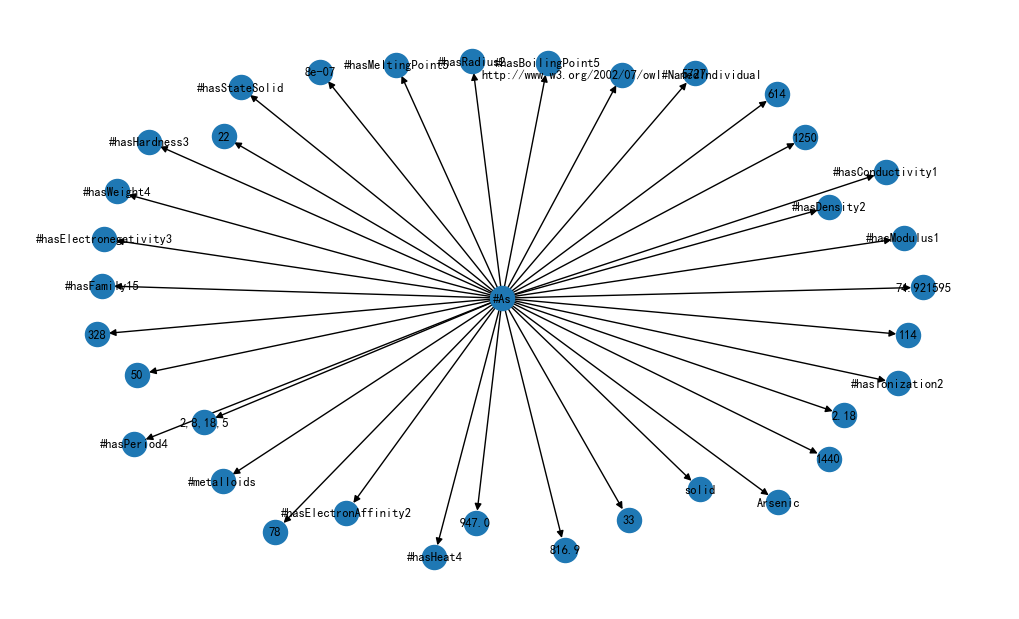

In [43]:
sub_graph = nx.generators.ego_graph(graph_2, '#As', radius=1,undirected=True)
ppp = sub_graph

plt.rcParams['font.sans-serif'] = ['Simhei']  #显示中文
plt.rcParams['axes.unicode_minus'] = False    #显示负号
pos = nx.spring_layout(ppp)
#colors= [G.nodes[n]['color'] for n in G.nodes()]

plt.figure(figsize=(10, 6))
nx.draw(ppp, pos=pos, with_labels=True,font_size=9)
edge_labels = nx.get_edge_attributes(ppp, 'relatio')
nx.draw_networkx_edge_labels(ppp, pos=pos, edge_labels=edge_labels)
plt.show()

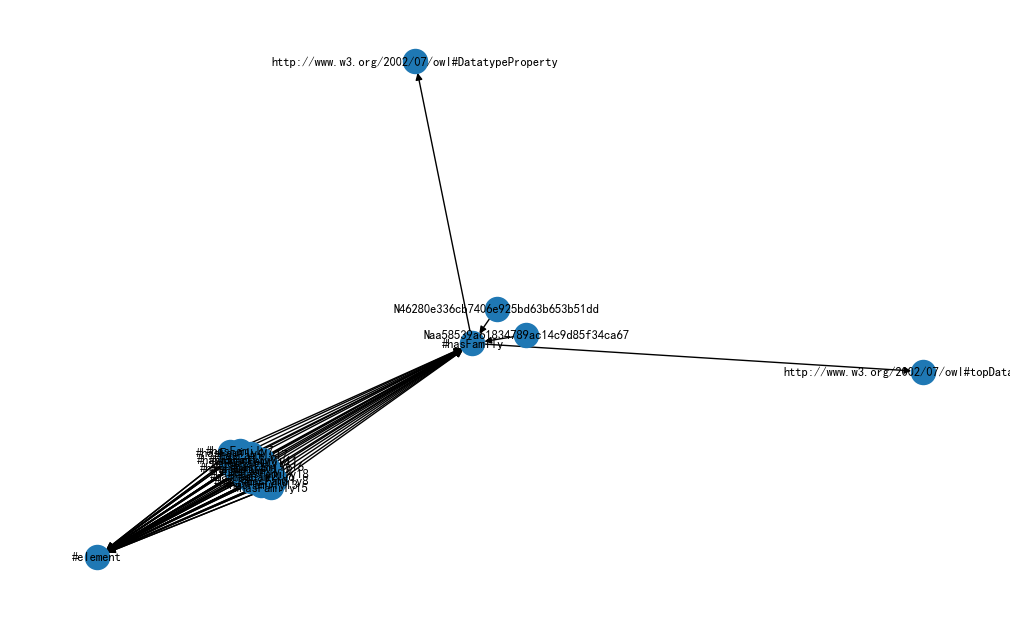

In [39]:
sub_graph = nx.generators.ego_graph(graph_2, '#hasFamily', radius=1,undirected=True)
ppp = sub_graph

plt.rcParams['font.sans-serif'] = ['Simhei']  #显示中文
plt.rcParams['axes.unicode_minus'] = False    #显示负号
pos = nx.spring_layout(ppp)
#colors= [G.nodes[n]['color'] for n in G.nodes()]

plt.figure(figsize=(10, 6))
nx.draw(ppp, pos=pos, with_labels=True,font_size=9)
edge_labels = nx.get_edge_attributes(ppp, 'relatio')
nx.draw_networkx_edge_labels(ppp, pos=pos, edge_labels=edge_labels)
plt.show()

In [40]:
for i in sub_graph.edges(data=True):
    print(i)

('Naa58539a61834789ac14c9d85f34ca67', '#hasFamily', {'relation': 'http://www.w3.org/1999/02/22-rdf-syntax-ns#first'})
('#hasFamily11', '#element', {'relation': 'http://www.w3.org/2000/01/rdf-schema#domain'})
('#hasFamily11', '#element', {'relation': 'http://www.w3.org/2000/01/rdf-schema#range'})
('#hasFamily11', '#hasFamily', {'relation': 'be subnode of'})
('#hasFamily12', '#element', {'relation': 'http://www.w3.org/2000/01/rdf-schema#range'})
('#hasFamily12', '#element', {'relation': 'http://www.w3.org/2000/01/rdf-schema#domain'})
('#hasFamily12', '#hasFamily', {'relation': 'be subnode of'})
('N46280e336cb7406e925bd63b653b51dd', '#hasFamily', {'relation': 'http://www.w3.org/1999/02/22-rdf-syntax-ns#first'})
('#hasFamily8', '#element', {'relation': 'http://www.w3.org/2000/01/rdf-schema#range'})
('#hasFamily8', '#element', {'relation': 'http://www.w3.org/2000/01/rdf-schema#domain'})
('#hasFamily8', '#hasFamily', {'relation': 'be subnode of'})
('#hasFamily', '#element', {'relation': 'htt

In [41]:
# 将graph2保存为本地文件
nx.write_gexf(graph_2, r'G:\Research\Paper4-Code\2024_5_13\Datasets\Knowledge graph(chemistry)\knowledge_graph.gexf')


In [173]:
print(len(entities),len(relations))
# 查找relations中没有出现在entities中的元素，打印
for i in relations:
    if i not in entities:
        print(i)

1804 120
http://www.w3.org/2000/01/rdf-schema#domain
http://www.w3.org/2000/01/rdf-schema#subPropertyOf
http://www.w3.org/2000/01/rdf-schema#subClassOf
http://www.w3.org/2002/07/owl#disjointWith
http://www.w3.org/2002/07/owl#members
http://www.w3.org/2000/01/rdf-schema#range
http://www.w3.org/1999/02/22-rdf-syntax-ns#type
http://www.w3.org/1999/02/22-rdf-syntax-ns#first
http://www.w3.org/1999/02/22-rdf-syntax-ns#rest


In [147]:
import networkx as nx
new_graph = nx.DiGraph()
# 将relf格式的g转换为new_graph
new_graph.add_nodes_from(entities, bipartite=0)
new_graph.add_nodes_from(relations, bipartite=1)

for s,p,o in triples:
    new_graph.add_edge(s, o,attr=p)
#    new_graph.add_edge(p, o)
#new_graph.add_edges_from([(s, p) for s, p, o in triples if p in relations])
#new_graph.add_edges_from([(p, o) for s, p, o in triples if p in relations])

In [151]:
# 查找new_graph中没有任何连线的节点
isolated_nodes = [n for n in new_graph.nodes() if new_graph.degree(n) == 0]
print('Isolated nodes: %d' % len(isolated_nodes))
isolated_nodes

Isolated nodes: 9


['http://www.w3.org/2000/01/rdf-schema#domain',
 'http://www.w3.org/2000/01/rdf-schema#subPropertyOf',
 'http://www.w3.org/2000/01/rdf-schema#subClassOf',
 'http://www.w3.org/2002/07/owl#disjointWith',
 'http://www.w3.org/2002/07/owl#members',
 'http://www.w3.org/2000/01/rdf-schema#range',
 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type',
 'http://www.w3.org/1999/02/22-rdf-syntax-ns#first',
 'http://www.w3.org/1999/02/22-rdf-syntax-ns#rest']

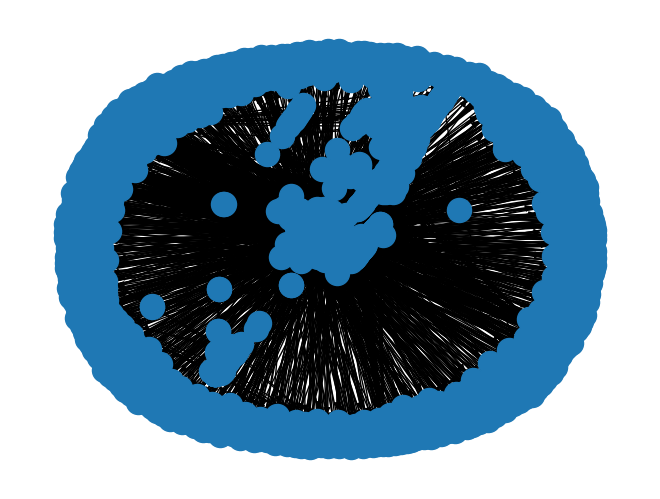

In [153]:
nx.draw(new_graph)

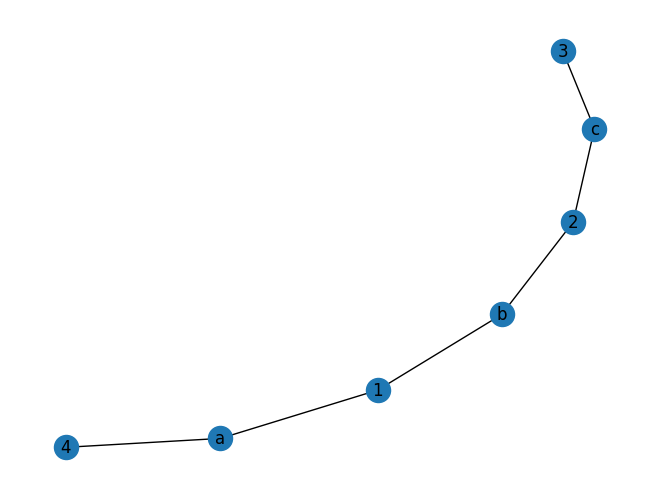

In [135]:
B = nx.Graph()

B.add_nodes_from([1,2,3,4]) # Add the node attribute "bipartite"

B.add_nodes_from(['a','b','c'])

B.add_edges_from([(1,'a'), (1,'b'), (2,'b'), (2,'c'), (3,'c'), (4,'a')])
#画出节点图以及节点的名字
nx.draw(B, with_labels=True)


In [121]:
entity_id, relation_id = dict(), dict()
for i, entity in enumerate(entities):
    entity_id[entity] = i
for i, relation in enumerate(relations):
    relation_id[relation] = i

In [65]:
with open(os.path.join('./', 'relation2id.txt'), 'w') as f:
    f.write('%d\n' % len(relations))
    for i, relation in enumerate(relations):
        f.write('%s\t%d\n' % (relation, i))

In [34]:
from rdflib.extras import external_graph_libs

In [35]:
external_graph_libs._rdflib_to_networkx_graph

<function rdflib.extras.external_graph_libs._rdflib_to_networkx_graph(graph: 'Graph', nxgraph, calc_weights: 'bool', edge_attrs, transform_s=<function _identity at 0x0000018DCABCA4D0>, transform_o=<function _identity at 0x0000018DCABCA4D0>)>

In [41]:
new_graph.edges()

EdgeView([('919.9', 'http://www.semanticweb.org/ElementKG#La'), ('568', 'http://www.semanticweb.org/ElementKG#Pa'), ('http://www.semanticweb.org/ElementKG#Hydroperoxy', 'http://www.semanticweb.org/ElementKG#O'), ('http://www.semanticweb.org/ElementKG#Hydroperoxy', 'http://www.w3.org/2002/07/owl#NamedIndividual'), ('http://www.semanticweb.org/ElementKG#Hydroperoxy', 'http://www.semanticweb.org/ElementKG#Hydroperoxide'), ('http://www.semanticweb.org/ElementKG#Hydroperoxy', 'http://www.semanticweb.org/ElementKG#H'), ('http://www.semanticweb.org/ElementKG#Hydroperoxy', 'single'), ('192', 'http://www.semanticweb.org/ElementKG#Ce'), ('2,8,18,18,3', 'http://www.semanticweb.org/ElementKG#In'), ('2,8,18,18,6', 'http://www.semanticweb.org/ElementKG#Te'), ('http://www.semanticweb.org/ElementKG#Amidine', 'Nfd1e49123c5b46ec8f536a42cce103e1'), ('http://www.semanticweb.org/ElementKG#Amidine', 'single'), ('http://www.semanticweb.org/ElementKG#Amidine', 'http://www.semanticweb.org/ElementKG#C'), ('http

In [42]:
relations

['http://www.w3.org/2000/01/rdf-schema#domain',
 'http://www.semanticweb.org/ElementKG#hasBoilingPoint2',
 'http://www.semanticweb.org/ElementKG#hasPeriod6',
 'http://www.semanticweb.org/ElementKG#hasHardness',
 'http://www.w3.org/2000/01/rdf-schema#subPropertyOf',
 'http://www.semanticweb.org/ElementKG#hasPeriod4',
 'http://www.semanticweb.org/ElementKG#hasBoilingPoint6',
 'http://www.semanticweb.org/ElementKG#hasIonization2',
 'http://www.semanticweb.org/ElementKG#hasAtomic',
 'http://www.semanticweb.org/ElementKG#hasFamily3',
 'http://www.semanticweb.org/ElementKG#hasMeltingPoint',
 'http://www.semanticweb.org/ElementKG#hasDensity',
 'http://www.semanticweb.org/ElementKG#hasFamily13',
 'http://www.semanticweb.org/ElementKG#hasHardness2',
 'http://www.semanticweb.org/ElementKG#hasBoilingPoint8',
 'http://www.semanticweb.org/ElementKG#hasMeltingPoint7',
 'http://www.semanticweb.org/ElementKG#hasPeriod1',
 'http://www.semanticweb.org/ElementKG#hasPeriod2',
 'http://www.semanticweb.org/